## 📘Основи комп’ютерного зору  

---

## 🚀 Вступ  

Комп’ютерний зір — це галузь машинного навчання, яка дозволяє комп’ютерам "бачити" та інтерпретувати зображення і відео, подібно до людського зору.  

🔬 **Основні задачі комп’ютерного зору**:  
- 🔍 Класифікація зображень: визначення об’єктів (наприклад, кіт чи собака).  
- 🎯 Детекція об’єктів: знаходження та ідентифікація об’єктів.  
- 🖼 Сегментація: поділ зображення на значущі регіони.  
- 📷 Розпізнавання тексту та облич: OCR, біометрія.  
- 🩺 Медична діагностика: аналіз МРТ, рентгенів.  

Комп’ютерний зір використовується в автономних автомобілях, системах безпеки, AR/VR та соціальних мережах!  

---

## 🧠 Згорткові нейронні мережі (CNN)

**Згорткові нейронні мережі (CNN)** — основа комп’ютерного зору. Вони ефективно обробляють зображення, виділяючи ключові ознаки.

---

### 📐 Структура CNN

Загалом CNN складається з двох основних частин:

#### 1. 🔍 Feature extraction (виділення ознак)
Цей блок відповідає за побудову багатошарової репрезентації вхідного зображення:
- **Згорткові шари (Convolutional layers)** — застосовують фільтри (ядра), які виділяють локальні патерни (краї, кути, текстури).
- **Активаційні функції** — зазвичай ReLU, додає нелінійність для моделювання складних функцій.
- **Нормалізація (наприклад, BatchNorm)** — стабілізує та прискорює навчання.
- **Пулінг (Pooling)** — зменшує розмірність простору ознак, зберігаючи найважливішу інформацію (наприклад, MaxPooling).

> ✅ Результатом цього блоку є багатовимірний **тензор ознак (feature map)** — компактна, але інформативна репрезентація вхідного зображення.

#### 2. 🧩 Head (вивідний блок)
"Голова" — це частина мережі, яка інтерпретує ознаки та формує остаточний вихід. Вона може бути різною, залежно від типу задачі:

- **Класифікація**:  
  - Flatten → Fully Connected → Softmax / Sigmoid.
- **Регресія**:  
  - Flatten → Fully Connected → Лінійна активація.
- **Сегментація**:  
  - Транспоновані згортки (Upsampling) або U-Net архітектура.
- **Детекція об’єктів**:  
  - Голови типу YOLO / SSD, які прогнозують координати рамок і класи.
- **Сімантичне порівняння / embedding**:  
  - Голови, що виводять вектори фіксованої довжини (наприклад, у задачах пошуку чи кластеризації).

---

### 📐 Математичне формулювання згортки:  

Згортка — це операція, де фільтр (матриця, наприклад, 3×3) "ковзає" по зображенню:  

$$
z[i,j] = \sum_{m,n} I[i+m, j+n] \cdot K[m,n]
$$

- **I**: вхідне зображення.  
- **K**: ядро (фільтр).  
- **z**: вихідна карта ознак.  

---

## 🎯 Основні задачі комп’ютерного зору  

- **Класифікація зображень**:  
  Приклад: розпізнавання цифр (MNIST).  
- **Детекція об’єктів**:  
  Знаходження об’єктів та їх меж (YOLO, Faster R-CNN).  
- **Сегментація**:  
  - Семантична: класифікація пікселів (U-Net).  
  - Інстанс: розпізнавання окремих об’єктів (Mask R-CNN).  

---

## 🛠 Інструменти та бібліотеки  

- **OpenCV**: для обробки зображень.  
- **TensorFlow / PyTorch**: для створення та навчання CNN.  
- **Датасети**: MNIST, CIFAR-10, ImageNet.  

# Приклад CNN
Тренування MNIST використовуя згорткову нейромережу

## Розмірність даних в MLP

Багатошаровий перцептрон працює з даними розмірності `[B, N]`:

- B - Batch Size
- N - N features

## Розмірність даних в CNN

Згорткові мережі в pytorch працюють  з даними розмірності `[B, C, H, W]`:
 - B - Batch Size
 - C - Channel size
 - H - Height
 - W - Width

## Визначення моделі

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # Перший згортковий шар
        # Input channels: 1 (для чорно-білих зображень, наприклад MNIST)
        # Output channels: 32
        # Kernel size: 3x3
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        # Другий згортковий шар
        # Input channels: 32
        # Output channels: 64
        # Kernel size: 3x3. 64x32x3x3
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        # Пулінг шар
        # Kernel size: 2x2
        # Stride: 2 (щоб зменшити розмір у 2 рази)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # Повнозв'язний шар
        # Розмір входу залежить від розміру вхідного зображення та згорткових/пулінг шарів
        # Припустимо, вхідне зображення 28x28 (як MNIST), після двох conv+pool шарів
        # розмір буде 28/2/2 = 7. Кількість каналів 64.
        # Отже, вхідний розмір 64 * 7 * 7
        # Вихідний розмір: 10 (для класифікації 10 класів, наприклад цифр від 0 до 9)
        self.fc1 = nn.Linear(64 * 7 * 7, 10)

    def forward(self, x):
        # Застосовуємо перший згортковий шар, ReLU активацію та пулінг
        x = self.pool(F.relu(self.conv1(x))) # Bx32x14x14
        # Застосовуємо другий згортковий шар, ReLU активацію та пулінг
        x = self.pool(F.relu(self.conv2(x))) # Bx64x7x7
        # Вирівнюємо тензор для повнозв'язного шару
        x = x.view(-1, 64 * 7 * 7) # Bx64x7x7 -> Bx3136
        # Застосовуємо повнозв'язний шар
        x = self.fc1(x)
        return x

# Створюємо екземпляр моделі
model = SimpleCNN()

# Приклад використання (для демонстрації, без реального навчання)
# Створюємо фіктивний вхідний тензор (Batch size = 1, Channels = 1, Height = 28, Width = 28)
dummy_input = torch.randn(1, 1, 28, 28)

# Пропускаємо вхідний тензор через модель
output = model(dummy_input)

# Виводимо розмір вихідного тензора (для одного зображення, 10 класів)
print("Розмір вихідного тензора:", output.shape)
print("Вихідний тензор (логарифм ймовірностей):", output)

# Виводимо структуру моделі
print("\nСтруктура моделі:")
print(model)

# Додатково: Виведемо кількість параметрів моделі
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'\nКількість навчальних параметрів: {count_parameters(model)}')

Розмір вихідного тензора: torch.Size([1, 10])
Вихідний тензор (логарифм ймовірностей): tensor([[ 0.5340,  0.0355,  0.4253,  0.0006, -0.0790, -0.0686, -0.5351,  0.1272,
         -0.1681,  0.0663]], grad_fn=<AddmmBackward0>)

Структура моделі:
SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=10, bias=True)
)

Кількість навчальних параметрів: 50186


## Визначення датасету

In [2]:
import torchvision
import torchvision.transforms as transforms
import torch.optim as optim
from tqdm import tqdm
import torch.nn as nn
import torch

# Завантаження та підготовка датасету MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Замість того щоб загружати дані вручну як ми робили до цього, використаємо
# спеціальний клас із бібліотеки torchvision
trainset = torchvision.datasets.MNIST(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64,
                                          shuffle=True)

testset = torchvision.datasets.MNIST(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64,
                                         shuffle=False)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.16MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 238kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.03MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.0MB/s]


---

## ⚙️ Тренування моделей: CPU vs GPU

В глибокому навчанні, обчислення є дуже ресурсоємними. Тренування використовуючи CPU може займати багато годин або днів. Для того щоб прискорити обчислення, використовується GPU.


### 🎮 GPU (Graphics Processing Unit)

- **Переваги:**
  - Спеціалізований на масово-паралельні обчислення.
  - Прискорює тренування моделей у десятки або сотні разів.
  - Стандарт у глибинному навчанні (наприклад, NVIDIA CUDA, cuDNN).

- **Недоліки:**
  - Дорожчий (особливо серверні варіанти).
  - Вимагає налаштування середовища (драйвери, CUDA тощо).

### 📊 Порівняння швидкості

| Завдання                    | CPU (Intel i7) | GPU (NVIDIA RTX 3060) |
|----------------------------|----------------|------------------------|
| Класифікація CIFAR-10 (1 епоха) | ~5 хвилин       | ~20 секунд             |
| Тренування ResNet-18       | ~45 хвилин      | ~2 хвилини             |

## GPU в Google colab

На щастя google colab надає безкоштовний доступ до T4 GPU карти. Для того щоб іі активувати, необхідно перейти `Runtime => Change Runtime Type` і обрати `T4 GPU`. Також можна обрати інші прискорювачі, але ця карта найпростіша в роботі.

Для CUDA GPU
pip uninstall torch torchvision torchaudio -y
pip cache purge
pip install torch torchvision torchaudio --index-url <a href="https://download.pytorch.org/whl/cu128" rel="noreferrer noopener" title="https://download.pytorch.org/whl/cu128" target="_blank">https://download.pytorch.org/whl/cu128</a>

In [3]:
import torchvision
import torchvision.transforms as transforms
import torch.optim as optim
from tqdm import tqdm
import torch.nn as nn

# Визначення пристрою (GPU, якщо доступно, інакше CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
model.to(device)

# Визначення функції втрат та оптимізатора
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)

# Навчання моделі
epochs = 2 # Кількість епох для навчання

for epoch in range(epochs):
    running_loss = 0.0
    # Використовуємо tqdm для відображення прогресу
    for images, labels in tqdm(trainloader, desc=f'Epoch {epoch+1}/{epochs}'):
        # Переміщуємо дані на пристрій
        images, labels = images.to(device), labels.to(device)

        # Обнуляємо градієнти оптимізатора
        optimizer.zero_grad()

        # Прямий прохід
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Зворотний прохід та оптимізація
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f'Epoch {epoch+1}, Loss: {running_loss/len(trainloader)}')

print('Finished Training')

# Оцінка моделі на тестовому датасеті
model.eval() # Переводимо модель в режим оцінки
correct = 0
total = 0
with torch.no_grad(): # Вимикаємо розрахунок градієнтів
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1) # Отримуємо індекс класу з найбільшою ймовірністю
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the model on the 10000 test images: {100 * correct / total}%')

2.13.0+cpu
None
False


Epoch 1/2: 100%|██████████| 938/938 [00:15<00:00, 59.83it/s]


Epoch 1, Loss: 1.8502346305196473


Epoch 2/2: 100%|██████████| 938/938 [00:15<00:00, 61.19it/s]


Epoch 2, Loss: 0.775984943326094
Finished Training
Accuracy of the model on the 10000 test images: 87.42%


## 🏛 Класичні архітектури CNN  

Згорткові нейронні мережі еволюціонували від простих моделей до складних архітектур, які стали основою сучасного комп’ютерного зору. Ось огляд ключових архітектур, що змінили гру:  

### 🔬 LeNet (1998)  
- **Особливості**: перша успішна CNN, розроблена для розпізнавання рукописних цифр (MNIST).  
- **Структура**: кілька згорткових шарів, пулінг, повнозв’язні шари.  
- **Застосування**: розпізнавання символів у чеках.  

### 🌟 AlexNet (2012)  
- **Особливості**: перемога в ImageNet (ILSVRC 2012), популяризувала глибоке навчання.  
- **Інновації**: використання ReLU, Dropout, GPU для прискорення.  
- **Структура**: 8 шарів (5 згорткових + 3 повнозв’язні).  
- **Застосування**: класифікація зображень із великою кількістю класів.  

### 🏗 VGG (2014)  
- **Особливості**: глибші мережі (16–19 шарів), використання маленьких фільтрів 3×3.  
- **Переваги**: простота та універсальність.  
- **Недоліки**: велике споживання пам’яті.  
- **Застосування**: класифікація, основа для інших задач.  

### 🔄 ResNet (2015)  
- **Особливості**: введення "залишкових з’єднань" (residual connections) для дуже глибоких мереж (до 152 шарів).  
- **Інновації**: дозволяє уникнути проблеми зникнення градієнта.  
- **Застосування**: класифікація, детекція, сегментація.  

### 🚀 Інші варіаціі  
- **EfficientNet**: баланс між точністю та ефективністю за допомогою масштабування.  
- **MobileNet**: легкі моделі для мобільних пристроїв.  
- **Vision Transformers (ViT)**: альтернатива CNN, заснована на трансформерах.  

Ці архітектури заклали фундамент для сучасних моделей комп’ютерного зору і часто використовуються як основа для transfer learning.  

**Порада**: використовуйте попередньо навчені моделі з бібліотек, таких як `torchvision.models`, для швидкого старту!  

In [4]:
# Визначення моделі ResNet34
model = torchvision.models.resnet34(pretrained=True) # Використовуємо попередньо навчену модель

# Замінюємо вихідний шар, щоб він відповідав кількості класів у вашому датасеті (наприклад, 10 для MNIST)
# Кількість вхідних ознак для останнього шару
num_ftrs = model.fc.in_features
# Замінюємо останній повнозв'язний шар на новий з 10 вихідними класами
model.fc = nn.Linear(num_ftrs, 10)

# Визначаємо пристрій (GPU, якщо доступно, інакше CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Визначення функції втрат та оптимізатора
# Для класифікації зазвичай використовують CrossEntropyLoss
criterion = nn.CrossEntropyLoss()
# Можна використовувати різні оптимізатори, наприклад Adam
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Навчання моделі
epochs = 2 # Кількість епох для навчання (може знадобитися більше)

for epoch in range(epochs):
    model.train() # Переводимо модель в режим навчання
    running_loss = 0.0
    # Використовуємо tqdm для відображення прогресу
    for images, labels in tqdm(trainloader, desc=f'Epoch {epoch+1}/{epochs}'):
        # Переміщуємо дані на пристрій
        images, labels = images.to(device), labels.to(device)

        images = torch.cat([images, images, images], dim=1) # resnet очікує 3х канальну картинку на вхід

        # Обнуляємо градієнти оптимізатора
        optimizer.zero_grad()

        # Прямий прохід
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Зворотний прохід та оптимізація
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f'Epoch {epoch+1}, Loss: {running_loss/len(trainloader)}')

print('Finished Training ResNet34')

# Оцінка моделі на тестовому датасеті
model.eval() # Переводимо модель в режим оцінки
correct = 0
total = 0
with torch.no_grad(): # Вимикаємо розрахунок градієнтів
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        images = torch.cat([images, images, images], dim=1) # resnet очікує 3х канальну картинку на вхід
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1) # Отримуємо індекс класу з найбільшою ймовірністю
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of ResNet34 on the 10000 test images: {100 * correct / total}%')

C:\Users\My data\data\Python-AI\Projects\lesson-12-Computer-Vision\.venv\Lib\site-packages\torchvision\models\_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\My data\data\Python-AI\Projects\lesson-12-Computer-Vision\.venv\Lib\site-packages\torchvision\models\_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to C:\Users\user/.cache\torch\hub\checkpoints\resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:07<00:00, 11.8MB/s]
Epoch 1/2: 100%|██████████| 938/938 [02:22<00:00,  6.59it/s]


Epoch 1, Loss: 0.12958082185635197


Epoch 2/2: 100%|██████████| 938/938 [02:19<00:00,  6.72it/s]


Epoch 2, Loss: 0.05737690140020603
Finished Training ResNet34
Accuracy of ResNet34 on the 10000 test images: 99.09%


---

## 🔄 Transfer Learning (Перенесене навчання)

У прикладі вище ми використали одну з популярних архітектур для тренування на базі MNIST. Ви могли помітити, що під час першого запуску коду у логах з’явилось повідомлення про завантаження — це були **попередньо натреновані ваги моделі**.

Модель, яку ми використали, раніше була навчена на великому датасеті **ImageNet** — одному з найвідоміших наборів даних з мільйонами зображень, що охоплюють тисячі класів. Це означає, що ми **не тренували модель з нуля**, а скористалися вже готовими знаннями, які вона здобула раніше. Такий підхід називається **transfer learning** — перенесене навчання.

### 🧠 Що таке Transfer Learning?

Transfer Learning — це метод, коли модель, попередньо навчена на одній задачі, використовується як основа для іншої, зазвичай пов’язаної задачі. У контексті комп’ютерного зору це означає, що модель уже "бачила" багато зображень і навчилася розпізнавати базові патерни (лінії, форми, текстури), які є універсальними для багатьох задач.

### ✅ Переваги Transfer Learning:

- **Швидше тренування**: модель вже має "знання", тож потрібно оновлювати лише частину параметрів.
- **Менше даних**: не потрібно мати великий датасет для навчання.
- **Краще узагальнення**: попередні знання можуть допомогти уникнути перенавчання на малих наборах.

### 🔧 Як це працює технічно?

Є два основні підходи:
1. **Feature extraction (використання як фіксованого екстрактора ознак)**  
   Ми заморожуємо всі шари попередньо навченої моделі (не оновлюємо їх) і додаємо новий класифікатор, який тренуємо під нашу задачу.

2. **Fine-tuning (точне донавчання)**  
   Ми завантажуємо попередньо натреновану модель, частково або повністю "розморожуємо" шари і донавчаємо модель разом із новим класифікатором. Саме цей підхід ми використали вище.

---

## ⚙️ Оптимізатори: від SGD до Adam

У попередньому прикладі ми використовували оптимізатор `Adam` замість класичного `SGD`. Давайте розглянемо, що це означає і чому це важливо.

---

### 🔁 Що таке оптимізатор?

Оптимізатор — це алгоритм, який оновлює ваги моделі під час тренування, намагаючись мінімізувати функцію втрат (**loss function**).

Кожен оптимізатор має свої стратегії оновлення ваг, що впливають на:

- швидкість збіжності;
- стабільність навчання;
- якість розв'язку (локальні мінімуми, плато, переобучення тощо).

де `γ` — коефіцієнт моментуму.

---

## ⚙️ Основні оптимізатори в глибокому навчанні

У сучасному глибокому навчанні існує багато варіантів оптимізаторів. Ось список основних, які найчастіше використовуються:

---

### 1. 🧮 `SGD` — Stochastic Gradient Descent

- Базовий метод стохастичного градієнтного спуску.
- Оновлює ваги у напрямку градієнта втрат.
- Простий, але повільний.
- Чутливий до вибору `learning rate`.

$$
\theta_{t+1} = \theta_t - \eta \cdot \nabla_\theta L(\theta_t)
$$

---

### 2. 🌀 `SGD with Momentum`

- Враховує "інерцію" попередніх градієнтів.
- Дозволяє швидше проходити плато та обійти локальні мінімуми.

$$
v_{t+1} = \gamma \cdot v_t + \eta \cdot \nabla_\theta L(\theta_t)
$$

$$
\theta_{t+1} = \theta_t - v_{t+1}
$$

### 3. 📈 `RMSprop`

- Адаптує розмір кроку окремо для кожного параметра.
- Добре працює при нерівномірних градієнтах.
- Використовується часто в RNN та reinforcement learning.

---

### 4. ⚡ `Adam` — Adaptive Moment Estimation

- Поєднує ідеї `Momentum` та `RMSprop`.
- Адаптивно змінює learning rate для кожного параметра.
- Стабільний і швидкий.
- Найпопулярніший оптимізатор на сьогодні.

---

### 5. 🧠 `AdamW` — Adam with Weight Decay

- Варіант `Adam`, який правильно реалізує L2-регуляризацію.
- Використовується в більшості сучасних трансформерів.
- Краща генералізація порівняно з Adam.

---

### 6. 🧪 Інші оптимізатори (рідше, але цікаво):

- `Adagrad` — добре працює для розріджених даних.
- `Adadelta` — модифікація `Adagrad`, менш чутлива до початкового `lr`.
- `NAdam` — Adam з Nesterov momentum.
- `LAMB`, `Lion`, `AdaBelief`, `Lookahead` — новіші оптимізатори, що тестуються у великих моделях.

---

### ✅ Як обрати?

| Завдання                  | Рекомендований оптимізатор |
|---------------------------|-----------------------------|
| Класифікація зображень    | `SGD + Momentum`, `AdamW`   |
| Прототипування / NLP      | `Adam`, `AdamW`             |
| RNN / Time Series         | `RMSprop`, `Adam`           |
| Великі трансформери       | `AdamW`, `LAMB`             |

---

---

## 🧱 Від LeNet до ResNet: еволюція архітектур у комп’ютерному зорі

З моменту появи перших згорткових мереж архітектури значно еволюціонували. Але які проблеми були в старих архітектурах, котрі всі послідовники намагались вирішити?

### 🧨 Проблема затухаючих та вибухових градієнтів

Глибокі нейронні мережі мають десятки, сотні, а сьогодні — тисячі шарів. Але зі збільшенням глибини виникає критична проблема: **градієнт** (сигнал для оновлення ваг) або:

- **Затухає** (наближається до нуля) — параметри не оновлюються, і мережа "завмирає".
- **Вибухає** (стає надто великим) — ваги стають нестабільними, і модель "розвалюється".

### Причини:
- Активаційні функції (особливо sigmoid/tanh), які "стискають" значення.
- Неправильно ініціалізовані ваги.
- Відсутність шляхів для прямого переносу інформації через глибину.

---

### 🐣 LeNet-5 (1998)

- **Особливості:**
  - Складається зі згорткових шарів, tanh-активацій, pooling'у та повнозв’язних шарів.
  - ~60 тис. параметрів.
  - **Активація:** використовувалась функція **tanh** або іноді **sigmoid**, яка вже на той час була стандартною.

> 🧠 LeNet заклала основи CNN, але мала обмежену глибину. Через використання sigmoid/tanh, вона частково страждала від **затухаючих градієнтів**, особливо при спробі побудувати глибші варіанти.

---

### 📈 AlexNet (2012)

- **Нововведення:** ReLU-активації, які частково вирішили проблему затухаючих градієнтів.

---

### 🧠 VGGNet (2014)

- Глибші архітектури до 19 шарів, уніфіковані 3×3 згортки.
- Проблема: мережа дуже глибока → **градієнти починають затухати**, тренування ускладнюється.

---

### 🔍 GoogLeNet / Inception (2014)

- Глибина: до 22 шарів.
- Архітектура оптимізована для ефективності (менше параметрів).
- Хитра структура допомогла частково обійти проблему затухання, але її не вирішувала повністю.

---

### 🪜 ResNet (2015): Розв’язання проблеми затухаючих градієнтів

- **Проблема:** класичне тренування глибоких мереж (30+ шарів) погіршує точність — навіть гірше, ніж у "мілких" моделей.
- **Рішення:** **ResNet** ввела **residual-з’єднання** — шляхи, які дозволяють градієнтам протікати в обхід основного блоку

![image](https://d2l.ai/_images/resnet-block.svg)

---

## 🧠 Семантична сегментація

Семантична сегментація — це задача, в якій **кожному пікселю зображення присвоюється клас**, наприклад "небо", "будівля", "дорога", "людина" тощо.

> 🎯 На відміну від класифікації (один клас на все зображення), семантична сегментація працює **на рівні пікселів**, даючи повну карту об'єктів у сцені.

![image](https://i0.wp.com/cdn-images-1.medium.com/max/850/1*f6Uhb8MI4REGcYKkYM9OUQ.png?w=850&resize=850,662&ssl=1)

---

### 📥 Вхід → 📤 Вихід

- **Вхід:** RGB-зображення (наприклад, 256×256×3)
- **Вихід:** карта класів (256×256), де кожен піксель має значення класу

---

### 🧱 Типова архітектура

Семантична сегментація часто використовує **encoder–decoder** структуру:

- **Encoder**: витягує просторові ознаки (на базі ResNet, VGG тощо)
- **Decoder**: відновлює карту пікселів до початкового розміру
- **Skip connections**: з'єднують шари енкодера і декодера, допомагаючи краще зберігати локальні деталі

---

### 🔧 Популярні архітектури

| Архітектура | Особливості                              | Переваги                              |
|-------------|-------------------------------------------|----------------------------------------|
| **U-Net**   | Encoder-decoder з skip-зʼєднаннями         | Дуже точна, працює на малих датасетах |
| **DeepLabv3+** | Atrous convolutions + encoder-decoder   | Сильна на великих зображеннях         |
| **SegFormer** | Transformer-базована сегментація         | Сучасний підхід, без згорток           |

---

### 🧪 Функції втрат

Для навчання використовуються функції, які оцінюють **відмінність між передбаченою маскою та реальною**:

- `CrossEntropyLoss` — стандарт для багатокласової сегментації
- `Dice Loss` — часто використовується в біомедицині (краще працює при сильному дисбалансі класів)
- Комбіновані втрати: `0.5 * CrossEntropy + 0.5 * Dice`

---

### 🧬 Приклади застосування

| Галузь         | Застосування                              |
|----------------|-------------------------------------------|
| Автономні авто | розпізнавання доріг, тротуарів, об’єктів |
| Медицина       | сегментація органів, пухлин, клітин       |
| Агрономія      | аналіз рослин на супутникових знімках     |
| Робототехніка  | орієнтація у просторі, розуміння сцени    |

---

### 📈 Метрики оцінки

| Метрика        | Опис                                                                 |
|----------------|----------------------------------------------------------------------|
| **IoU** (Jaccard Index) | перетин / об'єднання між передбаченим та істинним класом |
| **Pixel Accuracy**     | % правильно передбачених пікселів                          |
| **mIoU** (mean IoU)     | середнє IoU по всіх класах                                 |

---

### 🔍 Візуалізація (словами)

Уявіть: камера автомобіля знімає вулицю. Семантична сегментація "розфарбовує" зображення:

- небо — блакитне
- дорога — сіра
- пішоходи — червоні
- машини — сині

> 📦 У результаті модель має повне піксельне розуміння сцени. Це особливо корисно там, де важливе розділення об’єктів по областях, а не просто їх наявність.

---

### 🧠 Висновок

Семантична сегментація — це ключ до **глибокого просторового розуміння зображення**. Вона дозволяє:

- будувати карти сцени для автономного навігаційного контролю
- проводити детальний аналіз зображень в медицині
- адаптувати нейромережі до задач, де важлива **контекстуальна локалізація кожного пікселя**

---

## 🧬 U-Net


**U-Net** — це глибока нейронна мережа, спеціально розроблена для **семантичної сегментації**, особливо в медичних задачах. Вперше представлена в 2015 році для біомедичної сегментації клітин.

![image](https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/u-net-architecture.png)

> 📐 Назва "U-Net" походить від U-подібної форми архітектури: зліва — стиснення (encoder), справа — розгортання (decoder), а посередині — skip-зʼєднання.

---

### 🧱 Архітектура

U-Net складається з трьох основних частин:

1. **Encoder (контрактуюча частина)**  
   - Набір згортувальних шарів + max pooling
   - Зменшує просторовий розмір, витягуючи семантичні ознаки

2. **Decoder (розгортуюча частина)**  
   - Transposed convolutions (up-sampling)
   - Поступове відновлення розміру зображення

3. **Skip connections**  
   - Кожен шар енкодера напряму передає свої ознаки відповідному шару декодера
   - Це дозволяє **зберегти просторову інформацію**, яку втратили при стисненні
 

In [3]:
from torch import nn
import torch
from torch.nn import functional as F

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()

        # Encoder (Contracting Path)
        # Block 1
        self.enc1_conv1 = nn.Conv2d(in_channels, 64, kernel_size=3, padding=1)
        self.enc1_conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Block 2
        self.enc2_conv1 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.enc2_conv2 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Block 3
        self.enc3_conv1 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.enc3_conv2 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Block 4
        self.enc4_conv1 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.enc4_conv2 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Bottleneck
        self.bottleneck_conv1 = nn.Conv2d(512, 1024, kernel_size=3, padding=1)
        self.bottleneck_conv2 = nn.Conv2d(1024, 1024, kernel_size=3, padding=1)
        self.upconv4 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        # Decoder (Expanding Path)
        # Block 4
        self.dec4_conv1 = nn.Conv2d(1536, 512, kernel_size=3, padding=1) # 512 (from upconv) + 512 (from skip connection)
        self.dec4_conv2 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.upconv3 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        # Block 3
        self.dec3_conv1 = nn.Conv2d(768, 256, kernel_size=3, padding=1) # 256 (from upconv) + 256 (from skip connection)
        self.dec3_conv2 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.upconv2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        # Block 2
        self.dec2_conv1 = nn.Conv2d(384, 128, kernel_size=3, padding=1) # 128 (from upconv) + 128 (from skip connection)
        self.dec2_conv2 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.upconv1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        # Block 1
        self.dec1_conv1 = nn.Conv2d(192, 64, kernel_size=3, padding=1) # 64 (from upconv) + 64 (from skip connection)
        self.dec1_conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)

        # Output Layer
        self.output_conv = nn.Conv2d(64, out_channels, kernel_size=1)


    def forward(self, x):
        # Encoder
        enc1 = F.relu(self.enc1_conv1(x))
        enc1 = F.relu(self.enc1_conv2(enc1))
        enc1_pool = self.pool1(enc1)

        enc2 = F.relu(self.enc2_conv1(enc1_pool))
        enc2 = F.relu(self.enc2_conv2(enc2))
        enc2_pool = self.pool2(enc2)

        enc3 = F.relu(self.enc3_conv1(enc2_pool))
        enc3 = F.relu(self.enc3_conv2(enc3))
        enc3_pool = self.pool3(enc3)

        enc4 = F.relu(self.enc4_conv1(enc3_pool))
        enc4 = F.relu(self.enc4_conv2(enc4))
        enc4_pool = self.pool4(enc4)

        # Bottleneck
        bottleneck = F.relu(self.bottleneck_conv1(enc4_pool))
        bottleneck = F.relu(self.bottleneck_conv2(bottleneck))

        # Decoder
        dec4 = self.upconv4(bottleneck)
        # Concatenate with skip connection from encoder
        dec4 = torch.cat((dec4, enc4), dim=1)
        dec4 = F.relu(self.dec4_conv1(dec4))
        dec4 = F.relu(self.dec4_conv2(dec4))

        dec3 = self.upconv3(dec4)
        # Concatenate with skip connection from encoder
        dec3 = torch.cat((dec3, enc3), dim=1)
        dec3 = F.relu(self.dec3_conv1(dec3))
        dec3 = F.relu(self.dec3_conv2(dec3))

        dec2 = self.upconv2(dec3)
        # Concatenate with skip connection from encoder
        dec2 = torch.cat((dec2, enc2), dim=1)
        dec2 = F.relu(self.dec2_conv1(dec2))
        dec2 = F.relu(self.dec2_conv2(dec2))

        dec1 = self.upconv1(dec2)
        # Concatenate with skip connection from encoder
        dec1 = torch.cat((dec1, enc1), dim=1)
        dec1 = F.relu(self.dec1_conv1(dec1))
        dec1 = F.relu(self.dec1_conv2(dec1))

        # Output
        output = self.output_conv(dec1)

        return output

# Приклад використання:
# Створюємо екземпляр U-Net моделі
# in_channels=3 для RGB зображень, out_channels=1 для бінарної сегментації
unet_model = UNet(in_channels=3, out_channels=1)

# Переносимо модель на GPU, якщо доступно
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
unet_model.to(device)

# Створюємо фіктивний вхідний тензор (Batch size = 1, Channels = 3, Height = 256, Width = 256)
dummy_input_unet = torch.randn(1, 3, 256, 256).to(device)

# Пропускаємо вхідний тензор через модель
output_unet = unet_model(dummy_input_unet)

# Виводимо розмір вихідного тензора
print("Розмір вихідного тензора U-Net:", output_unet.shape)

# Виводимо структуру моделі
print("\nСтруктура моделі U-Net:")
print(unet_model)
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Виведемо кількість параметрів моделі U-Net
print(f'\nКількість навчальних параметрів U-Net: {count_parameters(unet_model)}')

device: cpu
Розмір вихідного тензора U-Net: torch.Size([1, 1, 256, 256])

Структура моделі U-Net:
UNet(
  (enc1_conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (enc1_conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2_conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (enc2_conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc3_conv1): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (enc3_conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc4_conv1): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (enc4_conv2): Conv2d(512, 512, kernel_size=(3, 3), str

In [4]:
import os
import tarfile
import urllib.request

# Створюємо папку для датасету
os.makedirs("OxfordPets", exist_ok=True)

# URL файлів
images_url = "https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz"
annotations_url = "https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz"

# Імена локальних файлів
images_file = "OxfordPets/images.tar.gz"
annotations_file = "OxfordPets/annotations.tar.gz"

print("Завантаження зображень...")
urllib.request.urlretrieve(images_url, images_file)

print("Завантаження анотацій...")
urllib.request.urlretrieve(annotations_url, annotations_file)

print("Розпакування images.tar.gz...")
with tarfile.open(images_file, "r:gz") as tar:
    tar.extractall("OxfordPets")

print("Розпакування annotations.tar.gz...")
with tarfile.open(annotations_file, "r:gz") as tar:
    tar.extractall("OxfordPets")

print("Готово!")

Завантаження зображень...
Завантаження анотацій...
Розпакування images.tar.gz...
Розпакування annotations.tar.gz...
Готово!


In [5]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms

# print("Hello")


class OxfordIIITPetDataset(Dataset):
    def __init__(self, img_dir, annotation_dir, transform=None):
        self.img_dir = img_dir
        self.annotation_dir = annotation_dir
        self.transform = transform

        # список усіх jpg-зображень
        self.img_files = sorted(
            [f for f in os.listdir(img_dir) if f.endswith(".jpg")]
        )

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):

        # шлях до зображення
        img_path = os.path.join(
            self.img_dir,
            self.img_files[idx]
        )

        # шлях до маски
        annotation_path = os.path.join(
            self.annotation_dir,
            "trimaps",
            self.img_files[idx].replace(".jpg", ".png")
        )

        # відкриваємо RGB-зображення
        image = Image.open(img_path).convert("RGB")

        # відкриваємо маску
        mask = Image.open(annotation_path).convert("L")

        # зміна розміру
        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)

        # перетворення у Tensor
        image = transforms.ToTensor()(image)

        # маска -> Tensor типу long
        mask = torch.from_numpy(np.array(mask)).long()

        return image, mask


# ----------------------------------------
# Трансформації
# ----------------------------------------

transform = transforms.Compose([
    transforms.Resize((256, 256))
])

# ----------------------------------------
# Шляхи до датасету
# ----------------------------------------

img_dir = "OxfordPets/images"
annotation_dir = "OxfordPets/annotations"

# ----------------------------------------
# Створення Dataset
# ----------------------------------------


train_dataset = OxfordIIITPetDataset(
    img_dir=img_dir,
    annotation_dir=annotation_dir,
    transform=transform
)

# ----------------------------------------
# DataLoader
# ----------------------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0
)

# ----------------------------------------
# Перевірка
# ----------------------------------------

images, masks = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Mask batch shape:", masks.shape)

print("Тип зображень:", images.dtype)
print("Тип масок:", masks.dtype)

print("Кількість зображень:", len(train_dataset))

Image batch shape: torch.Size([8, 3, 256, 256])
Mask batch shape: torch.Size([8, 256, 256])
Тип зображень: torch.float32
Тип масок: torch.int64
Кількість зображень: 7390


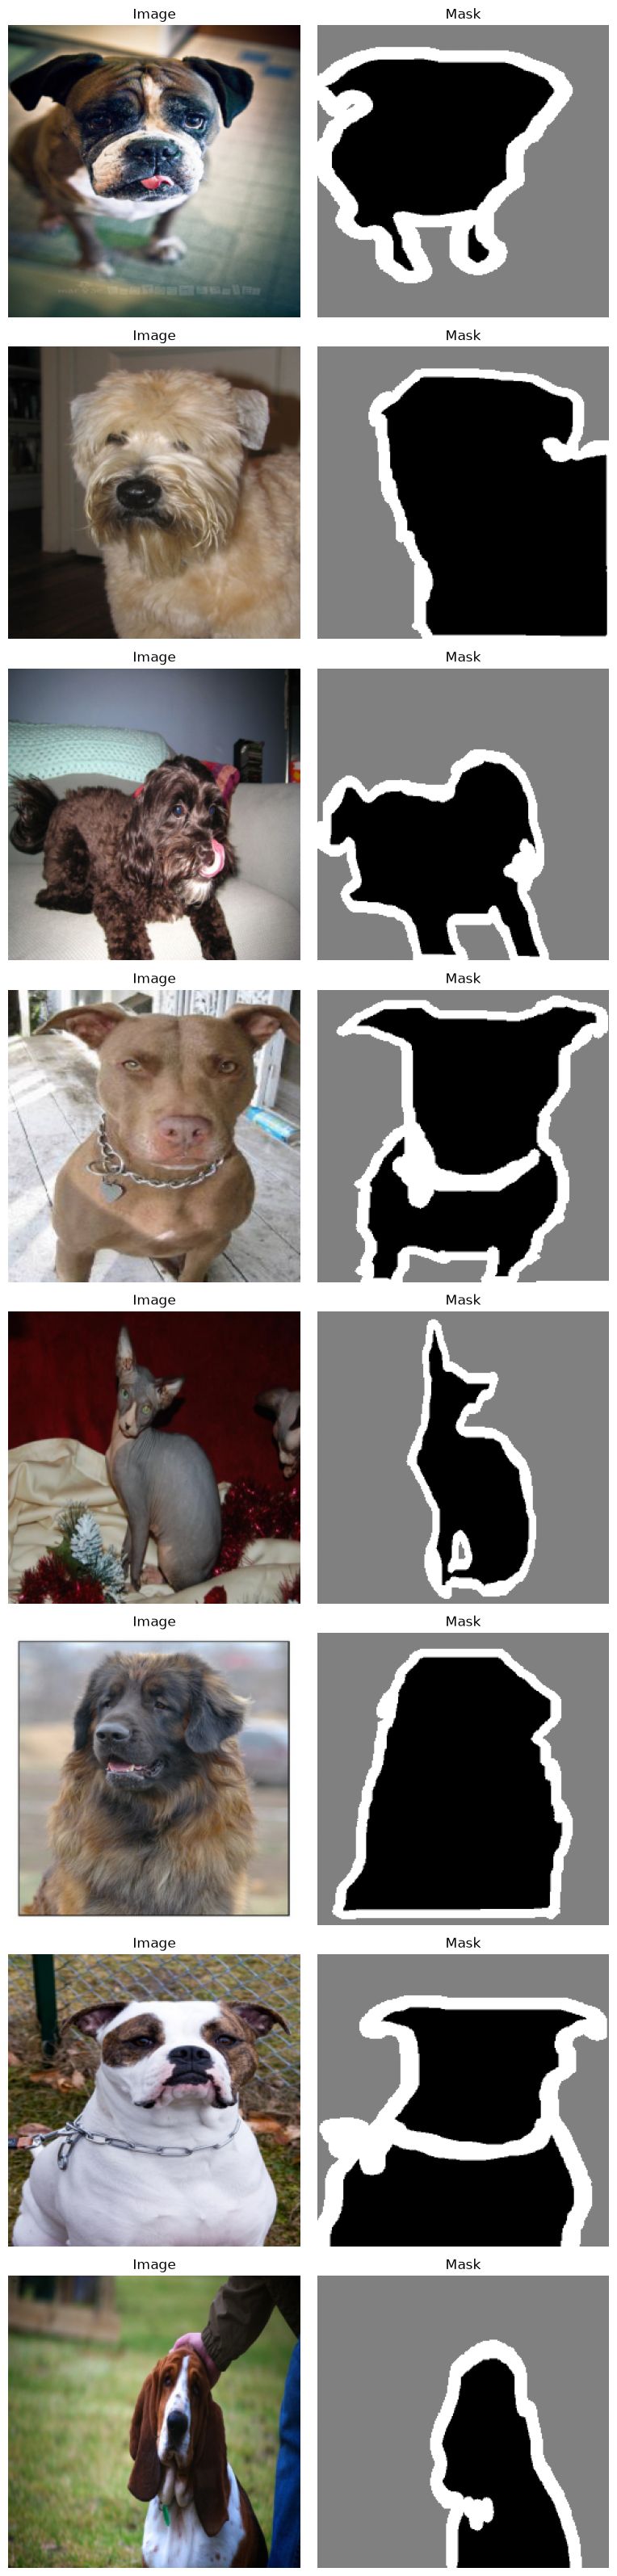

In [10]:

import matplotlib.pyplot as plt
import numpy as np

def visualize_examples(dataloader, num_examples=4):
    """Visualizes a few examples from the dataset."""
    images, masks = next(iter(dataloader))
    fig, axes = plt.subplots(num_examples, 2, figsize=(8, num_examples * 4))

    for i in range(num_examples):
        # Plot image
        img = images[i].permute(1, 2, 0).numpy()
        # Unnormalize if necessary, depends on the transform applied
        # For MNIST normalized to (0.5, ), we'd do:
        # img = img * 0.5 + 0.5
        img = np.clip(img, 0, 1) # Clip to [0, 1] for display
        axes[i, 0].imshow(img)
        axes[i, 0].set_title("Image")
        axes[i, 0].axis('off')

        # Plot mask
        # Squeeze the channel dimension if it exists for single channel masks
        mask = masks[i].squeeze().numpy()
        # Use 'gray' colormap for binary masks or a specific colormap for multi-class
        axes[i, 1].imshow(mask, cmap='gray')
        axes[i, 1].set_title("Mask")
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

# Visualize examples from the training dataset
visualize_examples(train_loader, num_examples=4)

In [ ]:
from torch import optim
from tqdm import tqdm

# Визначення пристрою (GPU, якщо доступно, інакше CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Створюємо екземпляр U-Net моделі
# out_channels=3, оскільки в нас три класи в масці (1, 2, 3)
unet_model = UNet(in_channels=3, out_channels=3)
unet_model.to(device)

# Визначення функції втрат та оптимізатора
# Для багатокласової сегментації використовуємо CrossEntropyLoss
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(unet_model.parameters(), lr=0.001)

# Навчання моделі U-Net
epochs = 1 # Можливо, знадобиться більше епох для кращого результату

for epoch in range(epochs):
    unet_model.train() # Переводимо модель в режим навчання
    running_loss = 0.0
    # Використовуємо tqdm для відображення прогресу
    for images, masks in tqdm(train_loader, desc=f'U-Net Epoch {epoch+1}/{epochs}'):
        # Переміщуємо дані на пристрій
        images, masks = images.to(device), masks.to(device)

        # Оскільки маски мають значення 1, 2, 3, віднімаємо 1, щоб вони стали 0, 1, 2
        # CrossEntropyLoss очікує цільові класи від 0 до C-1
        masks = masks - 1

        # Обнуляємо градієнти оптимізатора
        optimizer.zero_grad()

        # Прямий прохід
        outputs = unet_model(images)
        loss = criterion(outputs, masks)

        # Зворотний прохід та оптимізація
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f'U-Net Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}')

print('Finished Training U-Net')

# Функція для оцінки моделі (можна додати метрики IoU)
def evaluate_unet(model, dataloader, device):
    model.eval() # Переводимо модель в режим оцінки
    total_loss = 0.0
    # Можна додати метрики IoU тут

    with torch.no_grad(): # Вимикаємо розрахунок градієнтів
        for images, masks in tqdm(dataloader, desc='Evaluating U-Net'):
            images, masks = images.to(device), masks.to(device)
            masks = masks - 1 # Приводимо маски до діапазону [0, C-1]

            outputs = model(images)
            loss = criterion(outputs, masks)
            total_loss += loss.item()

            # Тут можна розрахувати IoU або інші метрики
            # predicted_masks = torch.argmax(outputs, dim=1)
            # print(predicted_masks.shape, masks.shape)

    avg_loss = total_loss / len(dataloader)
    print(f'Evaluation Loss: {avg_loss}')
    return avg_loss # Або повертати метрики

# Оцінка моделі на тестовому датасеті (якщо він є)
# На жаль, в OxfordIIITPetDataset немає вбудованого поділу на train/test
# Можна створити його вручну або використати частину train_dataset для оцінки
# evaluate_unet(unet_model, test_loader, device) # Якщо є test_loader
 

U-Net Epoch 1/1:  49%|████▊     | 449/924 [54:35<58:15,  7.36s/it]  

In [ ]:

import matplotlib.pyplot as plt
import numpy as np

# Функція для візуалізації прогнозу моделі U-Net
def visualize_unet_prediction(model, dataloader, device, num_examples=4):
    model.eval()  # Переводимо модель в режим оцінки
    images, masks = next(iter(dataloader)) # Беремо один батч
    images, masks = images.to(device), masks.to(device)

    with torch.no_grad():
        outputs = model(images)
        predicted_masks = torch.argmax(outputs, dim=1) # Отримуємо передбачені класи для кожного пікселя

    fig, axes = plt.subplots(num_examples, 3, figsize=(12, num_examples * 4))

    # Оскільки ми віднімали 1 від масок для CrossEntropyLoss,
    # додаємо 1 назад для візуалізації, щоб відповідало оригінальним значенням (1, 2, 3)
    masks = masks + 1
    predicted_masks = predicted_masks + 1


    for i in range(num_examples):
        # Plot original image
        img = images[i].permute(1, 2, 0).cpu().numpy()
        img = np.clip(img, 0, 1)
        axes[i, 0].imshow(img)
        axes[i, 0].set_title("Original Image")
        axes[i, 0].axis('off')

        # Plot Ground Truth Mask
        mask = masks[i].squeeze().cpu().numpy()
        axes[i, 1].imshow(mask, cmap='viridis') # Можна використовувати різні colormaps
        axes[i, 1].set_title("Ground Truth Mask")
        axes[i, 1].axis('off')

        # Plot Predicted Mask
        predicted_mask = predicted_masks[i].squeeze().cpu().numpy()
        axes[i, 2].imshow(predicted_mask, cmap='viridis')
        axes[i, 2].set_title("Predicted Mask")
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

# Візуалізуємо прогнози U-Net на кількох прикладах
visualize_unet_prediction(unet_model, train_loader, device, num_examples=4)
 